In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from scipy.stats import binomtest, ttest_ind, chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("train_data.csv")
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
91348,108635,15606267,Wilson,622,France,Female,35.0,7,98640.74,2,1.0,1.0,110457.99,1
2636,147941,15644891,Pirozzi,752,France,Female,32.0,2,0.00,1,1.0,0.0,159843.24,0
117007,88744,15702464,Watson,710,France,Male,31.0,4,0.00,3,0.0,0.0,160548.66,1
100279,125789,15701605,L?,704,Germany,Male,46.0,4,138912.17,1,0.0,1.0,141804.78,1
34835,135997,15757577,Hs?,675,Germany,Female,51.0,8,143390.51,1,1.0,0.0,168034.90,1


In [23]:
train_set["Exited"].value_counts()

Exited
0    90564
1    24299
Name: count, dtype: int64

On voit que les deux classes de la target sont assez désiquilibré et c'est pour cette raison qu'on utilisera la métrique f1_score. On va d'abords utiliser un modéle de régréssion logistique pour un premier modéle.

##I) Analyse fondamentale

#1) Définition des variables

•   Customer ID : Un identifiant unique pour chaque client (discret). Inutile pour le modéle.

•   Surname : Le nom de famille du client (discret). Inutile pour le modéle.

•   Credit Score : Une valeur numérique représentant le score de crédit du client (continue)

•   Geography : Le pays où réside le client (France, Spain ou Germany) (discret)

•   Gender : Le genre du client (Male or Female) (discret)

•   Age : L’âge du client (C'est une variable discréte mais qu'on va traiter comme une variable continue)

•   Tenure : Le nombre d’années pendant lesquelles le client est avec la banque (discret)

•   Balance : Le solde du compte du client (continue)

•   NumOfProducts : Le nombre de produits bancaires utilisés par le client (par exemple, compte d’épargne, carte de crédit) (discret)

•   HasCrCard : Si le client possède une carte de crédit (1 = oui, 0 = non) (discret)

•   IsActiveMember : Si le client est un membre actif (1 = oui, 0 = non) (discret)

•   EstimatedSalary : Le salaire estimé du client (continue)

•   Exited : Si le client a résilié (1 = oui, 0 = non) (discret)

•   Pour la définition des lignes, c'est les clients.

#2) Recherche bibliographique sur les principales raisons de résiliation de compte bancaires.

Selon ma recherche les principales raisons de résiliation de compte bancaire sont:

-Frais bancaires trop élevés ou conditions devenues défavorables : Des frais de tenue de compte jugés excessifs, des commissions élevées ou de nouvelles conditions tarifaires peuvent pousser un client à résilier son compte. En effet, beaucoup de clients refusent de « payer trop cher » leur banque et préfèrent aller vers une offre moins coûteuse. Par exemple, l’apparition de frais mensuels ou la facturation de services auparavant gratuits sont des motifs fréquents de fermeture par le titulaire du compte. -> https://www.nasdaq.com/articles/5-reasons-to-close-a-bank-account-2021-03-03#:~:text=2

-Insatisfaction vis-à-vis du service client ou de la qualité des services : Un mauvais service bancaire (conseillers peu disponibles, erreurs répétées, délais de traitement longs, etc.) incite également les clients à changer de banque. Près de 97 % des clients considèrent la qualité du service client comme un critère essentiel dans le choix de leur banque. Ainsi, un client confronté à un service médiocre ou à une relation de confiance dégradée pourra décider de clôturer son compte pour aller vers une banque plus à l’écoute de ses besoins. -> https://www.nasdaq.com/articles/5-reasons-to-close-a-bank-account-2021-03-03#:~:text=1,terrible

-Inactivité prolongée du compte (dormance) : L’absence de transactions pendant une longue période est l’un des motifs les plus répandus de clôture par la banque. Un compte sans mouvement pendant un certain temps est considéré comme inactif ou dormant. Dans de nombreux pays, la réglementation impose aux banques de clôturer ces comptes après des délais déterminés et de transférer les avoirs en déshérence à un fonds spécifique. Par exemple, en France, plus de 10,7 millions de comptes inactifs ont été fermés entre 2016 et 2021, leurs avoirs (7,18 milliards €) ayant été transférés à la Caisse des Dépôts. -> https://www.ar24.fr/banque-finance/cloture-compte-banque-motifs-courants/#:~:text=Dans%20un%20objectif%20de%20transparence%2C,au%20titulaire%20l%E2%80%99existence%20du%20compte et https://www.experian.com/blogs/ask-experian/reasons-bank-can-close-account/#:~:text=Your%20bank%20could%20decide%20to,your%20state%27s%20unclaimed%20property%20program

-Découverts non autorisés répétés et incidents de paiement : Une utilisation abusive conduisant à des découverts fréquents ou des chèques sans provision peut entraîner la résiliation par la banque. Si un client surveille mal son solde et accumule les incidents (prélèvements rejetés, chèques impayés), la banque y voit un risque financier et peut décider de fermer le compte. En pratique, trop de frais pour incident et une gestion déficiente du compte sont des causes reconnues de clôture unilatérale. Par exemple, une succession d’agios pour découverts non autorisés signalera à la banque que le client n’arrive pas à gérer son compte, justifiant une clôture selon la politique interne de l’établissement. -> https://www.ar24.fr/banque-finance/cloture-compte-banque-motifs-courants/#:~:text=2.%20Des%20d%C3%A9couverts%20non,r%C3%A9p%C3%A9tition et https://www.experian.com/blogs/ask-experian/reasons-bank-can-close-account/#:~:text=2,Bounced%20Checks%20or%20Overdraft%20Fees

-Compte au solde négatif persistant : Lié au point précédent, si le compte reste débiteur (négatif) pendant une durée prolongée sans régularisation, la banque peut le clôturer. Un compte dans le rouge signifie que le client doit de l’argent à la banque ; si cette situation perdure et empire, la banque choisira souvent de fermer le compte pour limiter ses pertes. Elle procèdera alors au recouvrement du solde dû auprès du client. En résumé, une banque n’a aucun intérêt à maintenir un compte continuellement débiteur et préfère y mettre fin contractuellement. -> https://www.experian.com/blogs/ask-experian/reasons-bank-can-close-account/#:~:text=3,Negative%20Balance

-Décès du titulaire du compte : Le décès n’est pas à proprement parler une « décision » de la banque, mais il conduit inévitablement à la clôture du compte. Juridiquement, dès qu’elle est informée du décès du client, la banque bloque le compte et aucune opération n’est plus possible. Ensuite, dans le cadre du règlement de la succession, le compte du défunt est fermé et son solde transféré aux héritiers ou à la succession. Si les ayants droit ne se manifestent pas, le compte finit par être déclaré inactif un an après le décès et les fonds sont éventuellement transférés à l’État passé un certain délai. La fermeture pour cause de décès est donc une procédure standard, bien que non initiée par la banque elle-même (elle intervient en exécution des dispositions légales sur les successions et comptes inactifs). -> https://www.lafinancepourtous.com/pratique/vie-perso/deces-d-un-proche/le-deces-et-ses-consequences-sur-les-contrats/le-deces-et-la-banque/#:~:text=D%C3%A9c%C3%A8s%20titulaire%20d%E2%80%99un%20compte%20bancaire, https://www.ar24.fr/banque-finance/cloture-compte-banque-motifs-courants/#:~:text=de%20recenser%20et%20de%20d%C3%A9clarer,au%20titulaire%20l%E2%80%99existence%20du%20compte et https://www.service-public.fr/particuliers/vosdroits/F31456#:~:text= 

-Décisions stratégiques de la banque : Parfois, la raison de la clôture est à chercher du côté de la politique interne de l’établissement. Les banques, en tant qu’entreprises, peuvent décider de fermer certains comptes pour optimiser leur rentabilité ou gérer leurs risques. Par exemple, un compte qui n’est pas rentable (très peu actif ou entraînant des coûts élevés de gestion) peut être clôturé dans une optique de maximisation du profit. De même, une évolution de la politique de risque (par exemple, la banque choisit de ne plus desservir un secteur jugé trop risqué ou controversé) peut entraîner la fermeture de comptes liés à ce secteur. Enfin, des raisons structurelles comme la fermeture d’une agence locale ou la fusion avec une autre banque peuvent conduire à des clôtures : lors d’une fusion, la nouvelle entité peut rationaliser les opérations en fermant des comptes en double ou redondants. Dans tous ces cas, le client est généralement informé à l’avance et se voit proposer des solutions alternatives (transfert vers une autre agence, ouverture d’un autre type de compte, etc.) -> https://www.index-immo.com/motifs-de-cloture-de-compte-par-la-banque-que-faire-si-cela-vous-arrive/#:~:text=,et%20%C3%A0%20votre%20profil%20d%27utilisateur

##II) Analyse statistiques

Dans cette section on va faire l'analyse statistique par raisons trouver durant l'analyse fondamentale. Pour éviter le biais de confirmation on va rediviser le train set en deux set, un set d'observation et un set de confirmation. Pour chaque raison on va sélectionner les variables intéréssante et on va toujours à la fin faire une études démographique par rapport à cette raison.

In [24]:
observation_set, confirmation_set = train_test_split(train_set, test_size=0.2, random_state=42)
print(len(confirmation_set))
len(observation_set)

22973


91890

#1) Frais bancaire trop élevées, objectif

Pour analyser cette raison on va utiliser la Balance, le nombre de produit, la possession d'une carte de crédit, la tenure et le salaire estimé. La balance va nous donner le montant du compte, plus la balance est moins élevé, moins le client peut se permettre de payer des frais supplémentaire. Le nombre de produit va nous montrer qu'il y a peut-être des produits gratuits qui sont devenus payant et donc qui font augmenter les frais. Quand on utilise une carte bancaire que ça soit une carte de crédit ou de débit, on doit payer des frais et par conséquent, si il y a augmentation de ces frais, cela peut faire fuir les clients. La tenure peut montrer les années dans lequel il y a plus de résiliation mais on peut aussi regarder l'évolution du nombres de compte résilié pour des clients avec un certain nombre de produit ou avec possession d'une carte de crédit pour essayer d'expliquer si il y a une différence durant certaines années qui peut montrer un changement de comportement des clients ce qui peut donner un indice par rapport à la raison des frais bancaires. Forcément, le salaire est important car si la personne à un petit salaire, il ne peut pas se permettre de payer beaucoup de frais. On sélectionnera aussi le pays de résidence, le genre et l'âge pour faire une étude démographique par rapport à cette raison.

1.1) Plan

1. Faire l'analyse univarié des variables sélectionner.

2. Analyse monétaires pour voir le nombre de résiliation en fonction de la situation financiéres des clients.

3. Etudes démographique de l'analyse monétaires si l'analyse à été intéréssante.

4. Analyse des variables de produits entre-eux et observation en fonction de la tenure pour voir si il y a un mouvement de résiliation à partir d'une valeur de tenure.

5. Etudes démographiques de l'analyse des variables produits.

1.2) Execution

1.2.1) Analyse univarié

1.2.1.a) Analyse des variables discrétes sélectionné

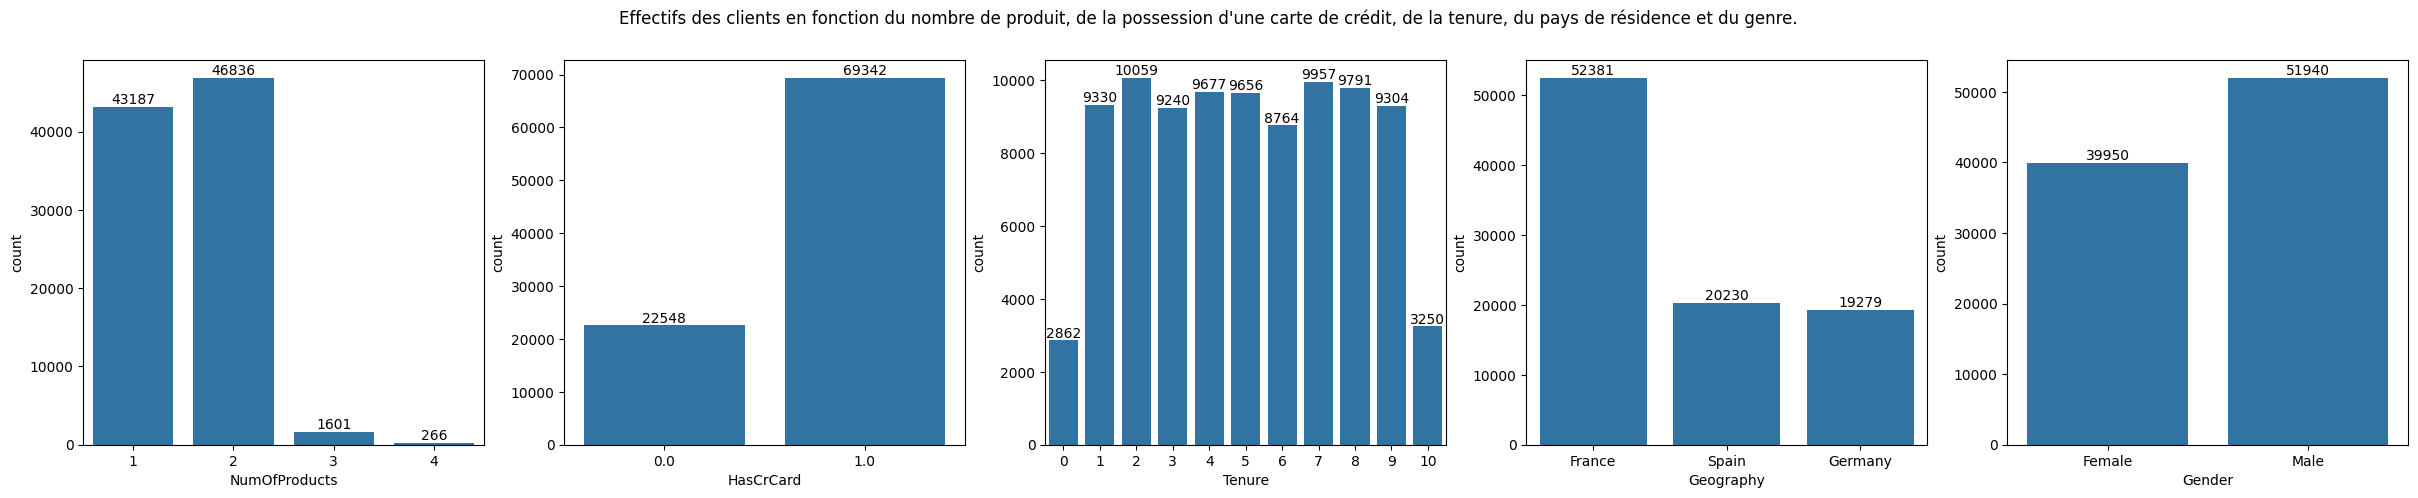

In [25]:
fig, ax = plt.subplots(1, 5)
fig.set_size_inches(30, 5)
plt.suptitle("Effectifs des clients en fonction du nombre de produit, de la possession d'une carte de crédit, de la tenure, du pays de résidence et du genre.")
sns.countplot(observation_set, x="NumOfProducts", ax=ax[0])
sns.countplot(observation_set, x="HasCrCard", ax=ax[1])
sns.countplot(observation_set, x="Tenure", ax=ax[2])
sns.countplot(observation_set, x="Geography", ax=ax[3])
sns.countplot(observation_set, x="Gender", ax=ax[4])
for ax_i in ax:
    for container in ax_i.containers:
        ax_i.bar_label(container)
plt.show()

On observe que la majorité des clients ont 1 et 2 produits et seulement une minorité qui ont 3 et 4 produit. Cela peut indiquer un manque de d'attractivité vis-à-vis de certains produits. On voit que la majorité des clients ont une carte de crédit et donc la majorité des clients peuvent emprunté de l'argent. Comme la tenure est le nombre d'années qu'un client est dans la banque, la premiére année de l'études de cette banque serait pour une valeur de tenure de 10 et la derniére année pour une valeur de 0. On voit que le nombre de client reste relativement constant pour des tenure de 1 à 9 mais les effectifs sont beaucoup plus petit pour des tenures de 0 et 10. La raison est que l'étude à été faites en cours d'année il y a dix ans puis l'année en cours n'est pas encore terminer. La plupart des clients vivent en France puis il y a un nombre similaires de clients qui vive en Espagne et en Allemagne. Il y a plus d'homme que de femmes dans le jeu d'observation. On va maintenant passer aux variables continues.

1.2.1.b) Analyse des variables continues

-Analyse des statistiques

In [26]:
observation_set["Balance"].describe()

count     91890.000000
mean      55788.947816
std       62839.546713
min           0.000000
25%           0.000000
50%           0.000000
75%      120105.430000
max      250898.090000
Name: Balance, dtype: float64

La moyenne des clients de cette banque qui vivent en France, en Allemagne et en Espagne est de 55788.948 euros avec un écart type de 62839.547 euros. On voit que la plupart des balances sont égales à 0 et que le maximum est un montant relativement élevé.

In [27]:
observation_set["Age"].describe()

count    91890.000000
mean        38.157453
std          8.870421
min         18.000000
25%         32.000000
50%         37.000000
75%         42.000000
max         92.000000
Name: Age, dtype: float64

La moyenne d'âge des clients de cette banque qui vive en France, Allemagne et Espagne est de 38 ans avec un écart-type de 9 ans. Le minimum est de 18 ans ce qui est normale car il faut avoir minimum 18 ans pour avoir un compte bancaire. 50% du jeu de données ont un âge inférieur à 37 ans ce qui est proche de la moyenne. L'âge maximum de ce jeu de donnée est de 92 ans qui est un âge d'un client trés âgé. Cela peut-être important pour la raison de décés. 

In [28]:
observation_set["EstimatedSalary"].describe()

count     91890.000000
mean     112621.931517
std       50206.691557
min          11.580000
25%       74835.650000
50%      117946.715000
75%      154886.290000
max      199992.480000
Name: EstimatedSalary, dtype: float64

La moyenne de salaire estimé des clients de cette banque qui vive en France, Allemagne et Espagne est de 112621.932 euros avec un écart-type de 50206.692 euros. Cette moyenne indique que beaucoup de salaire sont trés élevée si c'est des salaires mensuels. Donc c'est sûrement des salaires annuelles. Le minimum est une valeur trés particuliére car elle est impossible. Il y a donc des erreurs car on ne peut pas gagner moins que le smic pour les trois pays du jeu de donnée. Ce salaire est sûrement un salaire horaire. 50% des clients ont un salaire estimé inférieur à 117946.715 euros, ce qui veut dire que la plupart des salaires sont annuelle et trés élevé. Le salaires maximum est de 199992.480 euros qui est un salaires trés élevé.

-Analyse des répartitions

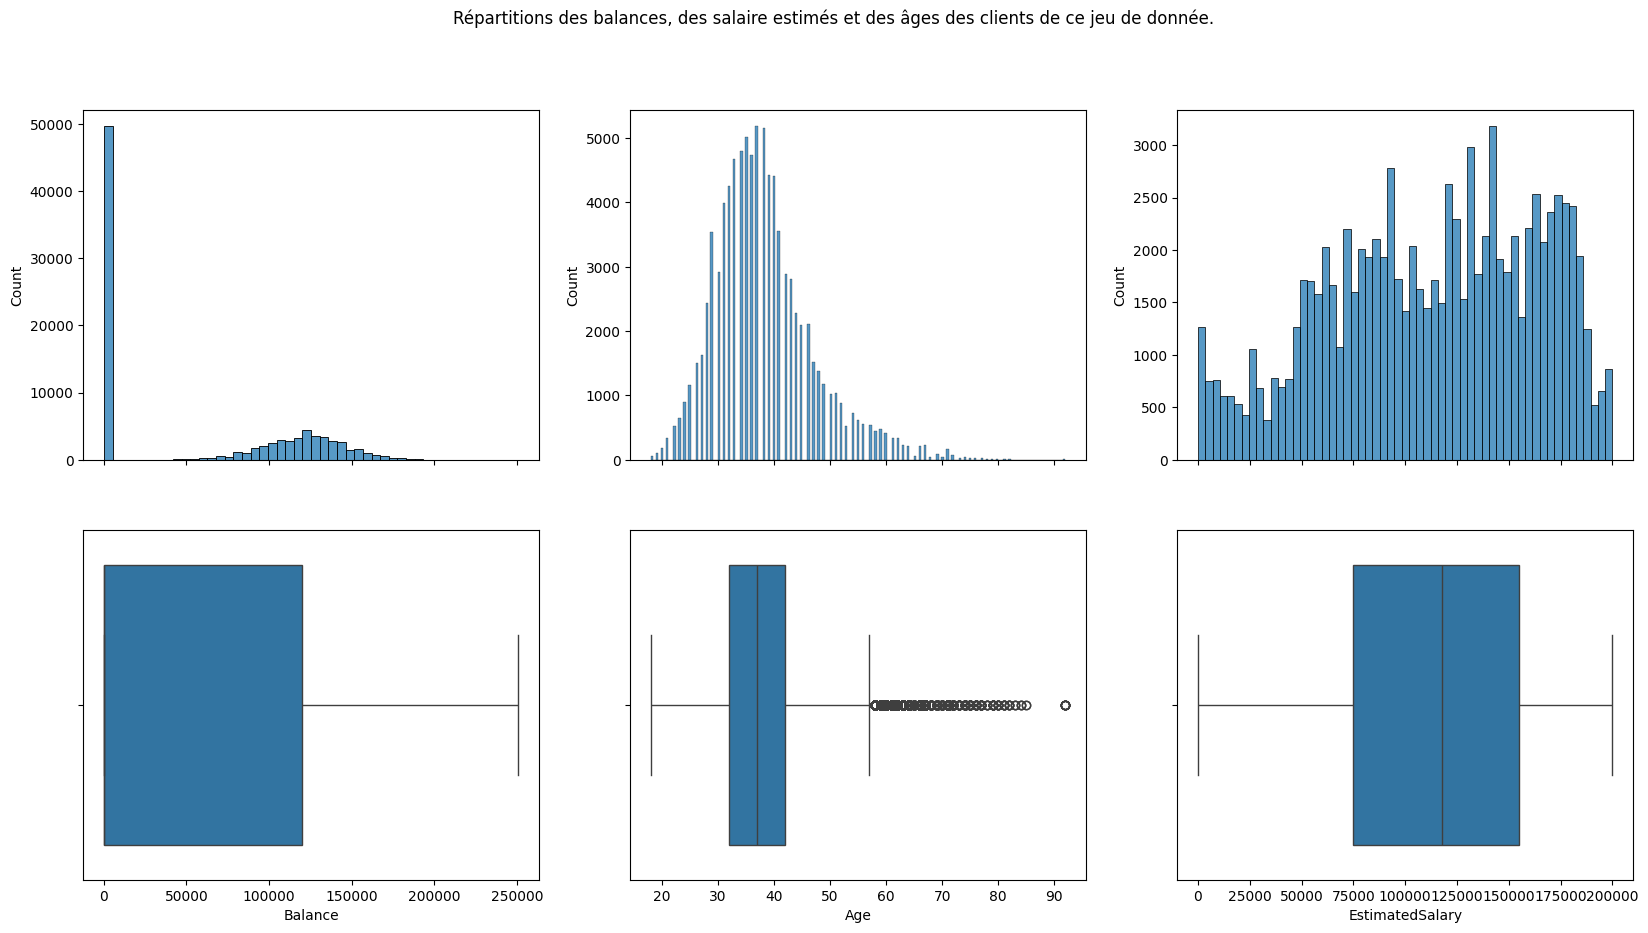

In [29]:
fig, ax = plt.subplots(2, 3, sharex='col')
fig.set_size_inches(20, 10)
plt.suptitle("Répartitions des balances, des salaire estimés et des âges des clients de ce jeu de donnée.")
sns.histplot(observation_set, x="Balance", ax=ax[0, 0])
sns.boxplot(observation_set, x="Balance", ax=ax[1, 0])
sns.histplot(observation_set, x="Age", ax=ax[0, 1])
sns.boxplot(observation_set, x="Age", ax=ax[1, 1])
sns.histplot(observation_set, x="EstimatedSalary", ax=ax[0, 2])
sns.boxplot(observation_set, x="EstimatedSalary", ax=ax[1, 2])
plt.show()

On voit une bar avec une loi normale pour la balance. On voit que la plupart des balances des clients de cette banque sont égale à 0. Il n'y a pas de valeurs abbérente dans la boxplot. Pour l'âge, on a une loi normale avec clairement des valeurs discrétes. La plupart des clients de cette banque ont entre 30 et 42 ans. On observe des valeurs considérée abbérantes à droite de la boxplot à partir de 58 ans. Le salaire n'est pas une loi normale ce qui est logique car il y a plusieurs types de salaire. La plupart sont annuelles mais certains sont horaires et même journaliére. Aucune valeurs abbérentes sont visibles dans la boxplot. Comme il y a plusieurs types de salaire et en plus on ne peut pas vraiment savoir comment le corriger car cela dépends de tous les types de salaires qu'il y a dans ce jeu de données. Par conséquent on supprimera cette varaible.


1.2.2) Analyse monétaires.

Pour faire cette analyse on va regarder la balance en fonction de la target et aussi de regarder le nombre de résiliation pour les balance égale à 0 et différent de 0.

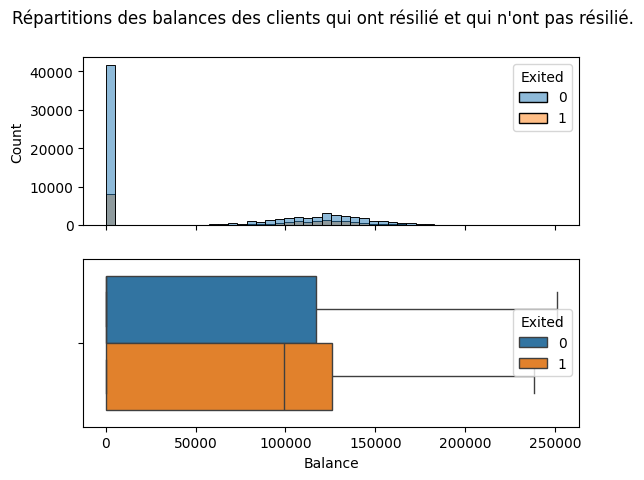

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,72414.0,51559.367699,62223.449376,0.0,0.0,0.00,116936.8175,250898.09
1,19476.0,71515.011414,62623.212003,0.0,0.0,99441.21,125683.5400,238387.56


In [30]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des balances des clients qui ont résilié et qui n'ont pas résilié.")
sns.histplot(observation_set, x="Balance", hue = "Exited", ax=ax[0])
sns.boxplot(observation_set, x="Balance", hue = "Exited", ax=ax[1])
plt.show()

observation_set.groupby("Exited")["Balance"].describe()

On voit que dans les deux classe de la target on a la plupart des clients qui ont une balance égale à 0 mais avec quand même une différences de balance différents de 0 et égale à 0 beaucoup plus grande pour le cas des clients qui n'ont pas résilié. On voit que la médiane de la balance des clients qui n'ont pas résilié est de 0 et pour les clients qui n'ont pas résilié, la médiane est de 99441.21 euros. On voit qu'il y a des grosses différences entre les moyennes mais on ne peut pas faire un test de student pour valider cette observation car la variable est juste normale si on enléve les balances égale à 0. On peut juste dire que la proportions des balances égale à 0 par rapport aux balance différent de 0 est beaucoup plus grande pour le cas des client qui n'ont pas résilié. Même si il n'y a pas de séparation dans la boxplot et l'histogramme, on peut utiliser le fait qu'il y a deux groupes différents, les balances égales à 0 et différents de 0. Cette variables est donc visiblement une variable qu'on va utiliser pour notre modéle. On voit que on ne peut pas en conclure que le manque d'argent est une raison pour résilié sur ce graphique car les balance égale à 0 peuvent être tous simplement des nouveau comptes. On va donc regarder que les balances différents de 0. Cette observation sera approfondie plus tard car on va se concentrer sur la premiére raison.

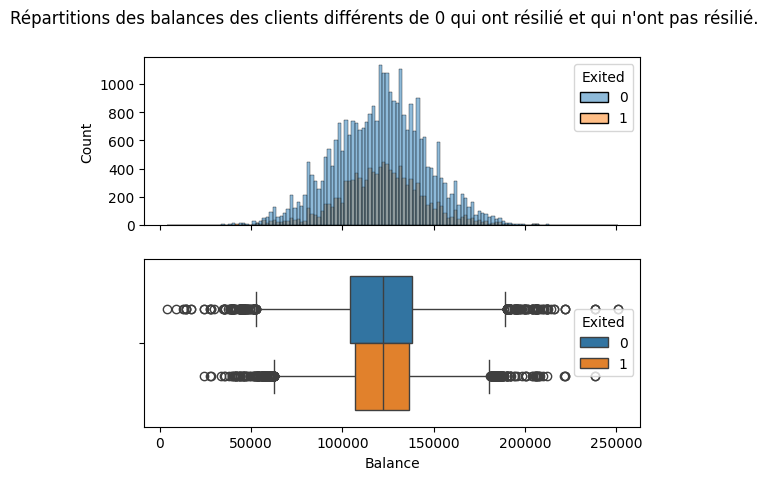

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,30790.0,121260.800667,25567.652682,3768.69,103907.2800,122314.53,137963.0700,250898.09
1,11438.0,121771.844928,23610.120526,24043.45,106939.3575,122022.29,136476.9575,238387.56


In [31]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Répartitions des balances des clients différents de 0 qui ont résilié et qui n'ont pas résilié.")
sns.histplot(observation_set.query("`Balance` != 0"), x="Balance", hue = "Exited", ax=ax[0])
sns.boxplot(observation_set.query("`Balance` != 0"), x="Balance", hue = "Exited", ax=ax[1])
plt.show()

observation_set.query("`Balance` != 0").groupby("Exited")["Balance"].describe()

On observe une belle loi normale pour les deux classes de la target. On observe que la plupart des clients qui résilie leurs compte avec une balance différentes de 0 ont une balance entre 100000 et 150000 euros. Cela nous montre que le manque d'argent sur le compte n'explique pas la volonté de quitter la banque. On ne va donc pas faire l'études démographique. On va passer au relation nombre de produit et tenure.

1.2.3) Nombre de produit et tenure.

Pour commencer cette analyse, on va regarder la relation entre le nombre de produit et la target.

In [51]:
pd.crosstab(observation_set["NumOfProducts"], observation_set["Exited"])

Exited,0,1
NumOfProducts,,
1,28216,14971
2,43977,2859
3,185,1416
4,36,230


In [52]:
pd.crosstab(observation_set["NumOfProducts"], observation_set["Exited"], normalize="index")

Exited,0,1
NumOfProducts,,
1,0.653345,0.346655
2,0.938957,0.061043
3,0.115553,0.884447
4,0.135338,0.864662


On voit qu'il y a beaucoup plus de client qui ont résilié que de client qui n'ont pas résilié pour des nombres de produits 3 et 4. On voit que la différence des clients qui n'ont pas résilié par rapport au clients qui ont résilié est est plus grande pour le nombre de produit 2 que pour le produit 1. On voit que effectivement, la plupart des clients qui ont 3 et 4 produit ont résilié ce qui montre peut-être que les frais de la plupart des produits ont été augmenter. Cela peut expliquer aussi que les clients sont déçues des produits mais ça c'est une autre raison qu'on verra plus tards. On va donc faire un test de chi2 de contingence pour vérifier la relation.

In [53]:
print("H0: Il n'y a pas de relation entre le nombre de produit et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(confirmation_set["NumOfProducts"], confirmation_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre le nombre de produit et la target.
Nous avons assez d'évidence pour rejeter H0.


Comme H0 à été rejeter, on peut affirmer avec un seuil alpha de 2% qu'il y a bien une relation intéréssante entre le nombre de produit et la target. Donc cette variable sera intéréssente pour le modéle. On va maintenant regarder de maniére générale la tenur en fonction du nombre de produit. On peut se poser la question, est-ce-que les clients qui ont une carte de crédit ont plus résilié que ceux qui n'ont pas de carte de crédit.

In [56]:
pd.crosstab(observation_set["HasCrCard"], observation_set["Exited"])

Exited,0,1
HasCrCard,,
0.0,17422,5126
1.0,54992,14350


In [57]:
pd.crosstab(observation_set["HasCrCard"], observation_set["Exited"], normalize='index')

Exited,0,1
HasCrCard,,
0.0,0.772663,0.227337
1.0,0.793055,0.206945


On remarque que pour les deux classes il y a plus de clients qui ont une carte de crédit et le taux de résiliation est légérement supérieur pour les clients qui n'ont pas de carte de crédit. A priori cette variable n'est pas trés intéréssente. On va donc d'abords tester la relation.

In [58]:
print("H0: Il n'y a pas de relation entre la possession d'une carte de crédit et la target.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(confirmation_set["HasCrCard"], confirmation_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il n'y a pas de relation entre la possession d'une carte de crédit et la target.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0, on peut affirmer avec un seuil aplha de 2% qu'il y a bien une relation entre la possession d'une carte de crédit et la target. Cela veut dire que la petite différence est assez significatif pour la considéré mais elle n'explique pas notre raison d'une augmentation de frais bancaire. On va donc regarder l'évolution des clients qui ont résilié en fonction de la tenure et aussi l'évolution du taux de résiliation pour les clietns qui ont uniquement une carte de crédit.

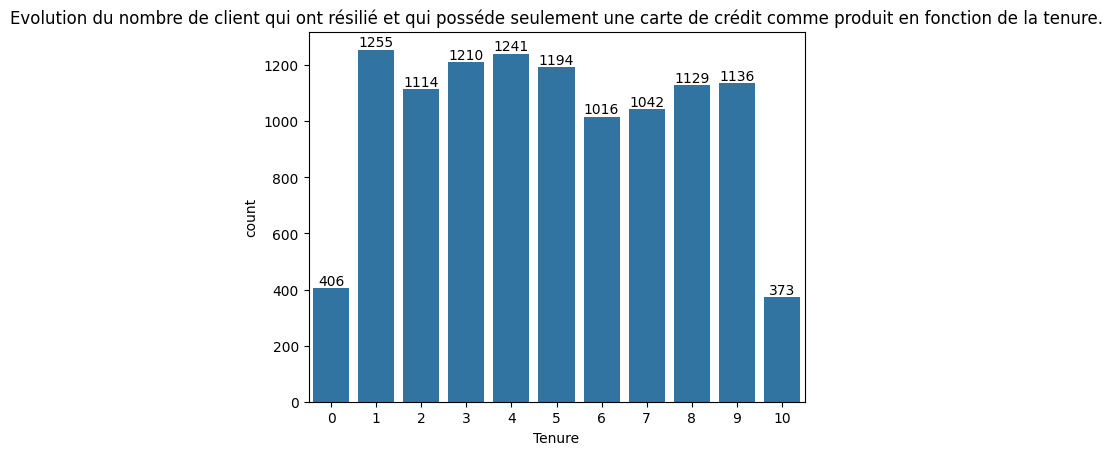

In [59]:
ax = sns.countplot(data=observation_set.query("`HasCrCard` == 1 and `NumOfProducts` == 1 and `Exited` == 1"), x="Tenure")
plt.title("Evolution du nombre de client qui ont résilié et qui posséde seulement une carte de crédit comme produit en fonction de la tenure.")
for container in ax.containers:
    ax.bar_label(container)
    plt.show()

On remarque quelque faible fluctuations. On observe une augmentation du nombre de résiliation entre l'année 4 (tenure = 6) et 6 (tenure = 5) avec une diminution pour l'année 8 (tenure=2). On à le plus grands départs de clients pour l'année la plus récente compléte (tenure=1). 